In [1]:
import numpy as np
import pandas as pd
import cv2
import os
import shutil
from tqdm import tqdm
import random
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
import keras
from keras import preprocessing
from keras import layers
from keras import models, Model
from tqdm import tqdm
from keras import regularizers
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam, SGD, RMSprop, Adamax
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import ResNet50, EfficientNetB3, DenseNet121, EfficientNetB0, EfficientNetB1
from tensorflow.keras.layers import Input
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D, Input
from keras.models import Sequential

%matplotlib inline
sns.set_style('darkgrid')
warnings.filterwarnings('ignore')

In [2]:
import zipfile
preprocessed_zip_path = "C:/Users/harma/OneDrive/Desktop/project2/data2/preprocessed_img_dataset.zip"

preprocessed_images = "C:/Users/harma/OneDrive/Desktop/project2/data2/preprocessed_images"

os.makedirs(preprocessed_images, exist_ok=True)

with zipfile.ZipFile(preprocessed_zip_path, 'r') as zip_ref:
    zip_ref.extractall(preprocessed_images)
    print(f"Preprocessed images extracted to: {preprocessed_images}")

Preprocessed images extracted to: C:/Users/harma/OneDrive/Desktop/project2/data2/preprocessed_images


In [3]:
train_df = pd.read_csv('C:/Users/harma/OneDrive/Desktop/project2/data2/balanced_labels.csv')
test_df = pd.read_csv('C:/Users/harma/OneDrive/Desktop/project2/data2/test.csv')
print(train_df.shape)
print(test_df.shape)

(4118, 2)
(1928, 1)


In [4]:
train_df.diagnosis.value_counts()

1    920
4    845
2    810
0    800
3    743
Name: diagnosis, dtype: int64

In [5]:
train_df.head()

,id_code,diagnosis
0,ef5155990874.png,0
1,0a85a1e8f9e9.png,0
2,6a2642131e4a.png,0
3,8a8a251770cd.png,0
4,ac1667fac512.png,0


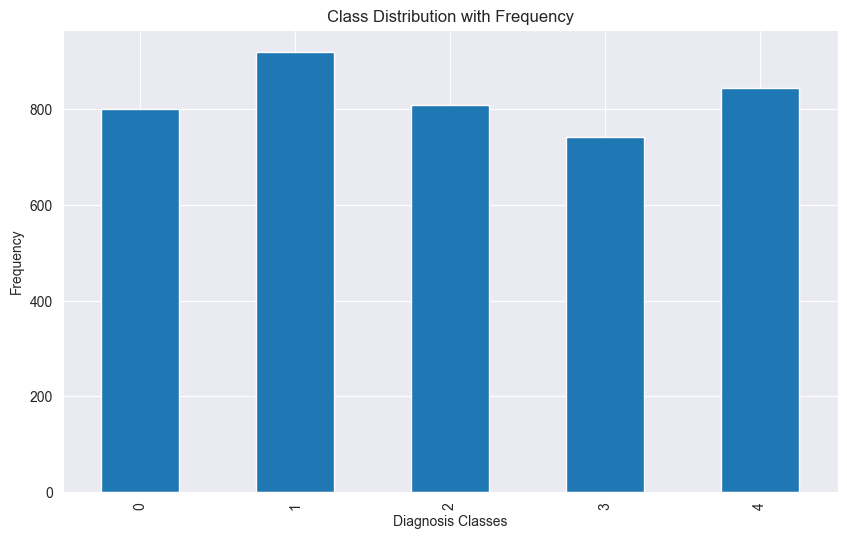

In [6]:
train_df.diagnosis.value_counts().sort_index().plot(kind='bar', figsize=(10,6), grid= True)
plt.title('Class Distribution with Frequency')
plt.xlabel('Diagnosis Classes')
plt.ylabel('Frequency')
plt.show()

In [9]:
import os
import cv2
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Set up augmentation parameters
augmentation_target = 2700  # Total images needed for class label 2
temp_augmented_dir = 'C:/Users/harma/OneDrive/Desktop/project2/data2/temporary_augmented_images'
preprocessed_images_dir = 'C:/Users/harma/OneDrive/Desktop/project2/data2/preprocessed_images'
os.makedirs(temp_augmented_dir, exist_ok=True)

# Load existing CSV file
csv_path = 'C:/Users/harma/OneDrive/Desktop/project2/data2/balanced_labels.csv'
train_df = pd.read_csv(csv_path)

# Define augmentation settings
augmentor = ImageDataGenerator(
    rotation_range=5,
    width_shift_range=0.005,
    height_shift_range=0.005,
    zoom_range=0.05,
    horizontal_flip=True,
    brightness_range=(0.9,1.1),
    fill_mode='reflect'
)

# List to hold new image data
new_data = []

# Get all existing image IDs
existing_ids = set(train_df['id_code'])

# Select only class 2 images for augmentation
class_2_df = train_df[train_df['diagnosis'] == 2]
num_existing = len(class_2_df)
num_needed = augmentation_target - num_existing  # Ensure exactly 2700 total images
print(f"Existing class 2 images: {num_existing}, Augmenting {num_needed} more images.")

# Augment class 2 images
augmented_images = []
for i in range(num_needed):
    row = class_2_df.sample(1).iloc[0]
    base_id = row['id_code'].split('.')[0]  # Remove extension
    img_path = os.path.join(preprocessed_images_dir, row['id_code'])

    if not os.path.exists(img_path):
        print(f"Warning: Image {img_path} not found.")
        continue

    img = cv2.imread(img_path)
    img = img.reshape((1,) + img.shape)
    aug_iter = augmentor.flow(img, batch_size=1)
    aug_img = next(aug_iter)[0].astype(np.uint8)

    # Generate unique new image name
    aug_index = 0
    while f"{base_id}_aug_{aug_index}.png" in existing_ids:
        aug_index += 1

    new_img_name = f"{base_id}_aug_{aug_index}.png"
    temp_img_path = os.path.join(temp_augmented_dir, new_img_name)

    # Save augmented image
    cv2.imwrite(temp_img_path, aug_img)
    augmented_images.append((aug_img, new_img_name, 2))
    existing_ids.add(new_img_name)  # Add to existing set to prevent duplicates

# Display up to 10 augmented images
print("Displaying up to 10 augmented images for class '2'...")
for idx, (aug_img, new_img_name, diagnosis) in enumerate(augmented_images[:10]):
    plt.imshow(cv2.cvtColor(aug_img, cv2.COLOR_BGR2RGB))
    plt.title(f"New Image ID: {new_img_name}\nLabel: {diagnosis}")
    plt.axis('off')
    plt.show()

# User confirmation before adding to dataset
user_input = input("Append these images to the main dataset? (y/n): ")
if user_input.lower() == 'y':
    for _, new_img_name, diagnosis in augmented_images:
        temp_img_path = os.path.join(temp_augmented_dir, new_img_name)
        final_img_path = os.path.join(preprocessed_images_dir, new_img_name)

        if os.path.exists(temp_img_path):
            shutil.move(temp_img_path, final_img_path)
            new_data.append({'id_code': new_img_name, 'diagnosis': diagnosis})
        else:
            print(f"Warning: Image {temp_img_path} not found when moving to final directory.")

    # Update the DataFrame and save to CSV
    if new_data:
        augmented_df = pd.DataFrame(new_data)
        train_df = pd.concat([train_df, augmented_df], ignore_index=True)
        train_df.to_csv(csv_path, index=False)
        print("Data augmentation completed. Updated training CSV and image directory.")
    else:
        print("No new images were appended.")
else:
    print("Skipping augmentation save.")


Existing class 2 images: 2700, Augmenting 0 more images.
Displaying up to 10 augmented images for class '2'...
Append these images to the main dataset? (y/n): y
No new images were appended.


In [8]:
train_df.diagnosis.value_counts()

2    2700
1     920
4     845
0     800
3     743
Name: diagnosis, dtype: int64

In [10]:
# Define the folder and zip file name
shutil.make_archive("C:/Users/harma/OneDrive/Desktop/project2/data2/new_preprocessed_images", 'zip', "C:/Users/harma/OneDrive/Desktop/project2/data2/preprocessed_images")

'C:\\Users\\harma\\OneDrive\\Desktop\\project2\\data2\\new_preprocessed_images.zip'